C:\Users\jmo007\AppData\Local\Temp\ipykernel_3912\2779021386.py:36: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle(
C:\Users\jmo007\AppData\Local\Temp\ipykernel_3912\2779021386.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  spacer = plt.Rectangle(
C:\Users\jmo007\AppData\Local\Temp\ipykernel_3912\2779021386.py:66: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle(


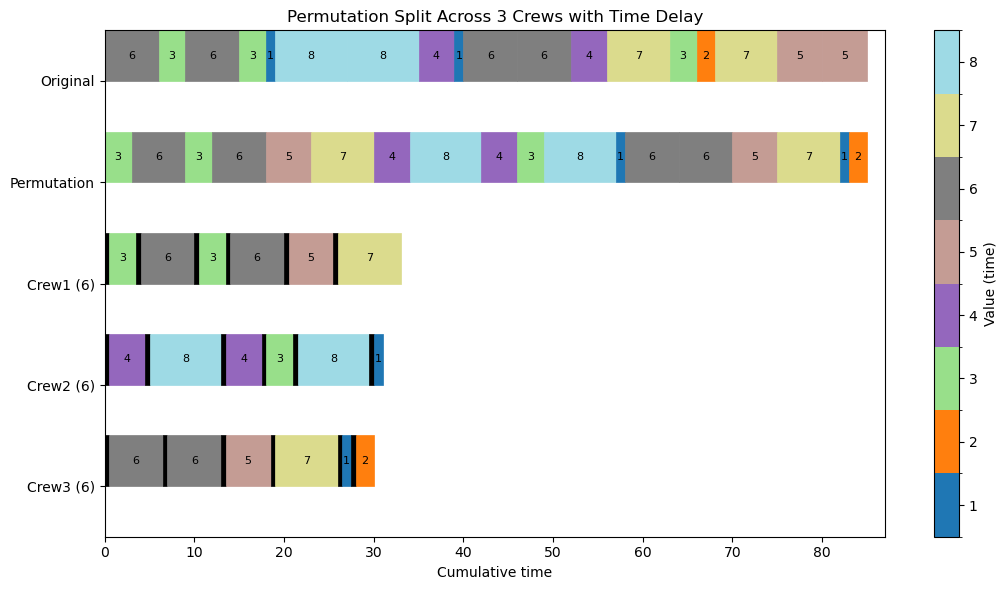

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# -----------------------------
# 1. Generate data (20 values)
# -----------------------------
nums = [random.randint(1, 8) for _ in range(18)]

# Create permutation
perm = nums.copy()
random.shuffle(perm)

# Split into 3 crews: 6, 6, 6
crew1 = perm[:6]
crew2 = perm[6:12]
crew3 = perm[12:]

# -----------------------------
# 2. Colormap (pastel categories)
# -----------------------------
cmap = plt.get_cmap('tab20', 8)
bounds = np.arange(1, 10) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# -----------------------------
# 3. Plot setup
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# Standard row (no spacer blocks)
def draw_row(values, y):
    x = 0
    for v in values:
        rect = plt.Rectangle(
            (x, y), v, 1,
            color=cmap(v-1),
            edgecolor='black',
            linewidth=0.5
        )
        ax.add_patch(rect)

        # label
        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v
    return x

# Crew row (with spacer blocks)
def draw_crew_row(values, y):
    x = 0
    for v in values:
        # spacer block (light blue, no label)
        spacer = plt.Rectangle(
            (x, y), 0.5, 1,
            color='black',#'lightblue',
            edgecolor='black',
            linewidth=0.5
        )
        ax.add_patch(spacer)
        x += 0.5

        # value block
        rect = plt.Rectangle(
            (x, y), v, 1,
            color=cmap(v-1),
            edgecolor='black',
            linewidth=0.5
        )
        ax.add_patch(rect)

        # label only for values
        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v
    return x

# -----------------------------
# 4. Draw rows
# -----------------------------
w1 = draw_row(nums, 3)      # Original
w2 = draw_row(perm, 1)      # Permutation

w3 = draw_crew_row(crew1, -1)
w4 = draw_crew_row(crew2, -3)
w5 = draw_crew_row(crew3, -5)

max_width = max(w1, w2, w3, w4, w5)

# -----------------------------
# 5. Colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, ticks=range(1, 9))
cbar.set_label("Value (time)")

# -----------------------------
# 6. Axes formatting
# -----------------------------
ax.set_xlim(0, max_width + 2)
ax.set_ylim(-6, 4)

ax.set_yticks([3, 1, -1, -3, -5])
ax.set_yticklabels([
    "Original",
    "Permutation",
    "Crew1 (6)",
    "Crew2 (6)",
    "Crew3 (6)"
])

ax.set_xlabel("Cumulative time")
ax.set_title("Permutation Split Across 3 Crews with Time Delay")

plt.tight_layout()
plt.show()